<a href="https://colab.research.google.com/github/Abebayehu-Alaro/Abebayehu-Alaro/blob/main/FacialRecognitionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Facial Recognition Using VGG16 and MTCNN by Abebayehu Alaro**

Changing Working directory to FacialRecognitionAttendanceSystem Directory

In [101]:
import os
os.chdir('/content/drive/Othercomputers/My Laptop/DjangoAttendance/FacialRecognitionBasedAttendanceSystem')

**Face Detection Using MTCNN**

Install MTCNN using pip package manager

In [10]:
pip install mtcnn


In [38]:
import numpy as np
from FacialRecognition.mtcnn_detector import MTCnnDetector
from FacialRecognition.vggModelFinal import VggModel
import FacialRecognition.constant
CELEBRITY_VGG_PATH='/content/drive/Othercomputers/My Laptop/DjangoAttendance/FacialRecognitionBasedAttendanceSystem/media/abi_bitse.jpg'


Detect Face and plot using *matplotlib*

1/1 [==============================] - 0s 179ms/step


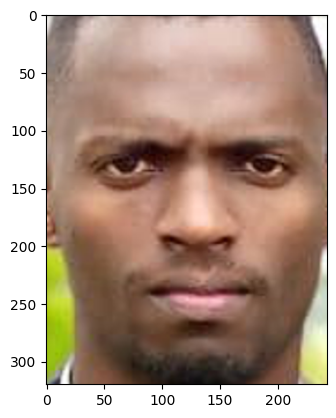

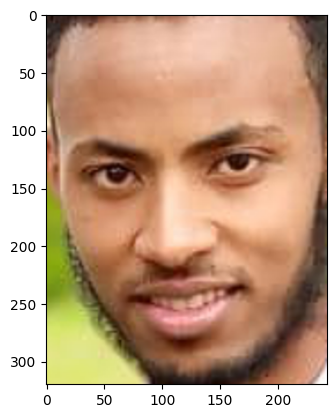

In [39]:
MTCnnDetector(CELEBRITY_VGG_PATH, False, True)

**Train Classfication Model VGG16**

Change image file extensions to jpg extension.

In [128]:

# Change to the directory
os.chdir('/content/Datasets')
index = 0
def change_file_extension(directory, new_ext):
    for root, dirs, files in os.walk(directory):
        index = 0
        for file in files:
            old_path = os.path.join(root, file)
            new_path = os.path.splitext(old_path)[0] + str(index)+ new_ext
            index = index + 1
            os.rename(old_path, new_path)

# Example usage: change all files in the current directory and its subdirectories to .jpg
change_file_extension('.', '.jpg')


In [ ]:
print(os.getcwd())
for file in files:
    print(file)

In [102]:
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from numpy import expand_dims
from tensorflow.keras import Input
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import MaxPooling2D, Dense, Flatten, Convolution2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from FacialRecognition.common import Common

In [120]:
class VggModel:
    def __init__(self):

        self.init_model()
        opt = keras.optimizers.Adam(learning_rate=0.001)
        self.vgg.compile(loss=keras.losses.binary_crossentropy,
                         optimizer=opt,
                         metrics=[FacialRecognition.constant.METRIC_ACCURACY])

    def init_model(self):

        base_model = VGG16(weights=FacialRecognition.constant.IMAGENET, include_top=False,
                           input_tensor=Input(shape=(FacialRecognition.constant.IMG_WIDTH,
                                                     FacialRecognition.constant.IMG_HEIGHT, 3)), pooling='max', classes=15)
        # base_model.summary()

        for layer in base_model.layers:
            layer.trainable = False

        x = base_model.get_layer('block5_pool').output
        # Stacking a new simple convolutional network on top of it
        x = Convolution2D(64, 3)(x)
        x = MaxPooling2D(pool_size=(2, 2))(x)
        x = Flatten()(x)
        x = Dense(FacialRecognition.constant.NUMBER_FULLY_CONNECTED, activation=FacialRecognition.constant.RELU_ACTIVATION_FUNCTION)(x)
        x = Dense(17, activation=FacialRecognition.constant.SOFTMAX_ACTIVATION_FUNCTION)(x)

        self.vgg = Model(inputs=base_model.input, outputs=x)
        self.vgg.summary()

    def train(self, num_epochs=10, num_batchs=10):

        datagen = ImageDataGenerator(rescale=1. / 255,
                                     shear_range=0.4,
                                     zoom_range=0.2,
                                     rotation_range=50,
                                     width_shift_range=0.2,
                                     height_shift_range=0.2,
                                     horizontal_flip=True,
                                     fill_mode='nearest')
        #
        traindata = datagen.flow_from_directory(
            directory="/content/Datasets/training_set",
            target_size=(FacialRecognition.constant.IMG_WIDTH,
                         FacialRecognition.constant.IMG_HEIGHT))

        testdata = datagen.flow_from_directory(
            directory="/content/Datasets/testing_set",
            target_size=(FacialRecognition.constant.IMG_WIDTH,
                         FacialRecognition.constant.IMG_HEIGHT))

        # checkpoint = ModelCheckpoint("vgg16_1.h5", monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=False, mode='auto', period=1)
        checkpoint = ModelCheckpoint("vgg16_1.h5", monitor=FacialRecognition.constant.METRIC_ACCURACY, verbose=1, save_best_only=True,
                                     save_weights_only=False, mode='auto', save_freq=1)
        # early = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=20, verbose=1, mode='auto')
        early = EarlyStopping(monitor=FacialRecognition.constant.METRIC_ACCURACY, min_delta=0, patience=20, verbose=1, mode='auto')
        self.vgg.fit_generator(steps_per_epoch=num_batchs, generator=traindata, validation_data=testdata,
                               validation_steps=10, epochs=num_epochs, callbacks=[checkpoint, early])


In [121]:
vgg = VggModel()


Model: "model_29"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_30 (InputLayer)       [(None, 320, 243, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 320, 243, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 320, 243, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 160, 121, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 160, 121, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 160, 121, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 80, 60, 128)       0  

In [122]:
vgg.train()

Found 0 images belonging to 16 classes.
Found 3 images belonging to 16 classes.


<ipython-input-120-d1d17169a5e2>:57: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  self.vgg.fit_generator(steps_per_epoch=num_batchs, generator=traindata, validation_data=testdata,


ValueError: ignored